# 01 · Data Acquisition — Real Macro Drivers
**Principle: real public / reference data first, synthetic business data second.**

This notebook inspects the *real* external data the project is built on: commodity, energy and FX series pulled from **FRED** (St. Louis Fed), plus a curated country reference table. Produced by `python -m src.data_acquisition`.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40, "display.width", 160)
from src import config as C
print("project root:", ROOT)

project root: D:\proyectos\porsche intership\Price Intelligence\automotive-procurement-price-intelligence


## Provenance
Every run records where each dataset came from (live FRED vs documented fallback).

In [2]:
import json
meta = json.loads(C.ACQUISITION_META.read_text())
print('window:', meta['window_start'], '->', meta['window_end'])
for d in meta['datasets']:
    print(f"  {d['dataset']:<26} source={d['source']:<24} rows={d['rows']}")

window: 2022-01-01 -> 2024-12-01
  commodity_index.csv        source=FRED live                rows=36
  energy_cost_index.csv      source=FRED live                rows=36
  exchange_rate_index.csv    source=FRED live                rows=36
  country_reference.csv      source=reference table (curated) rows=8


## The three real index series

In [3]:
com = pd.read_csv(C.COMMODITY_CSV, parse_dates=['date'])
ene = pd.read_csv(C.ENERGY_CSV, parse_dates=['date'])
fx  = pd.read_csv(C.EXCHANGE_CSV, parse_dates=['date'])
com.head()

Out[3]: 
        date  year  month  aluminum_usd_ton  copper_usd_ton  iron_ore_usd_ton  raw_material_index     source
0 2022-01-01  2022      1           3005.98         9782.34            133.05              100.00  FRED live
1 2022-02-01  2022      2           3245.79         9943.17            139.70              105.33  FRED live
2 2022-03-01  2022      3           3498.37        10230.89            147.35              111.43  FRED live
3 2022-04-01  2022      4           3246.99        10174.35            146.67              107.37  FRED live
4 2022-05-01  2022      5           2839.51         9395.03            131.09               95.95  FRED live


,date,year,month,aluminum_usd_ton,copper_usd_ton,iron_ore_usd_ton,raw_material_index,source
0,2022-01-01,2022,1,3005.98,9782.34,133.05,100.00,FRED live
1,2022-02-01,2022,2,3245.79,9943.17,139.70,105.33,FRED live
2,2022-03-01,2022,3,3498.37,10230.89,147.35,111.43,FRED live
3,2022-04-01,2022,4,3246.99,10174.35,146.67,107.37,FRED live
4,2022-05-01,2022,5,2839.51,9395.03,131.09,95.95,FRED live


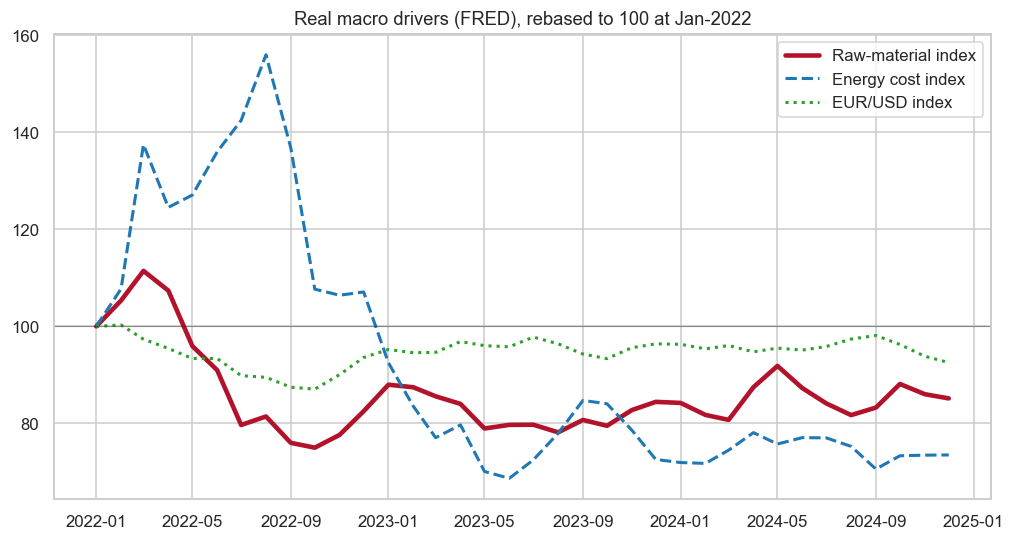

In [4]:
fig, ax = plt.subplots(figsize=(11,5.5))
ax.plot(com.date, com.raw_material_index, lw=3, color='#b3122b', label='Raw-material index')
ax.plot(ene.date, ene.energy_cost_index, lw=2, ls='--', color='#1f77b4', label='Energy cost index')
ax.plot(fx.date,  fx.exchange_rate_index, lw=2, ls=':', color='#2ca02c', label='EUR/USD index')
ax.axhline(100, color='k', lw=.8, alpha=.4)
ax.set_title('Real macro drivers (FRED), rebased to 100 at Jan-2022'); ax.legend(); plt.show()

**Read-out.** The data carries genuine economic history: the **2022 energy crisis** (energy index peaking ~156, +56%), cooling commodity markets afterwards, and a **weakening euro**. These real movements drive the synthetic prices in notebook 02.

In [5]:
country = pd.read_csv(C.COUNTRY_CSV)
country

Out[5]: 
          country         region     supplier_region currency  distance_to_germany_km  country_risk_score
0         Germany         Europe            Domestic      EUR                     250                  10
1  Czech Republic         Europe             EU-East      CZK                     350                  18
2          Poland         Europe             EU-East      PLN                     700                  22
3           Italy         Europe             EU-West      EUR                     750                  28
4           Spain         Europe             EU-West      EUR                    1600                  26
5           China           Asia        Asia-Pacific      CNY                   19000                  65
6          Mexico  North America  Nearshore-Americas      MXN                    9800                  48
7             USA  North America       North-America      USD                    7500                  30


,country,region,supplier_region,currency,distance_to_germany_km,country_risk_score
0,Germany,Europe,Domestic,EUR,250,10
1,Czech Republic,Europe,EU-East,CZK,350,18
2,Poland,Europe,EU-East,PLN,700,22
3,Italy,Europe,EU-West,EUR,750,28
4,Spain,Europe,EU-West,EUR,1600,26
5,China,Asia,Asia-Pacific,CNY,19000,65
6,Mexico,North America,Nearshore-Americas,MXN,9800,48
7,USA,North America,North-America,USD,7500,30
